## 1. Install Dependencies

In [1]:
!pip install transformers datasets torch scikit-learn pandas openpyxl==3.1.0 seaborn matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 7.5 MB/s eta 0:00:00


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
USE_GENERATED_DATASET = False
DATA_FOLDER_PATH = "../input/datasets/ilyakozhevnikov/combined-data/"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Load & Explore the Data

In [3]:
if USE_GENERATED_DATASET:
    DATA_PATH = DATA_FOLDER_PATH + "Mental_issues_dataset.xlsx"
    df = pd.read_excel(DATA_PATH)
else:
    DATA_PATH = DATA_FOLDER_PATH + "Combined Data.csv"
    df = pd.read_csv(
        DATA_PATH
    ).drop(
        columns=['Unnamed: 0']
    ).rename(
        columns={
            'statement': 'health_concerns',
            'status': 'class_txt'
        }
    )
    disease_to_class_num_sict = {}
    for class_num, disease in enumerate(df['class_txt'].unique()):
        disease_to_class_num_sict[disease] = class_num
    df['class_num'] = df['class_txt'].apply(lambda val: disease_to_class_num_sict[val])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (53043, 3)


,health_concerns,class_txt,class_num
0,oh my gosh,Anxiety,0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,0
3,I've shifted my focus to something else but I'...,Anxiety,0
4,"I'm restless and restless, it's been a month n...",Anxiety,0


In [4]:
# df['length'] = df['health_concerns'].apply(lambda val: len(str(val)))
# df[df['length'] == 2]

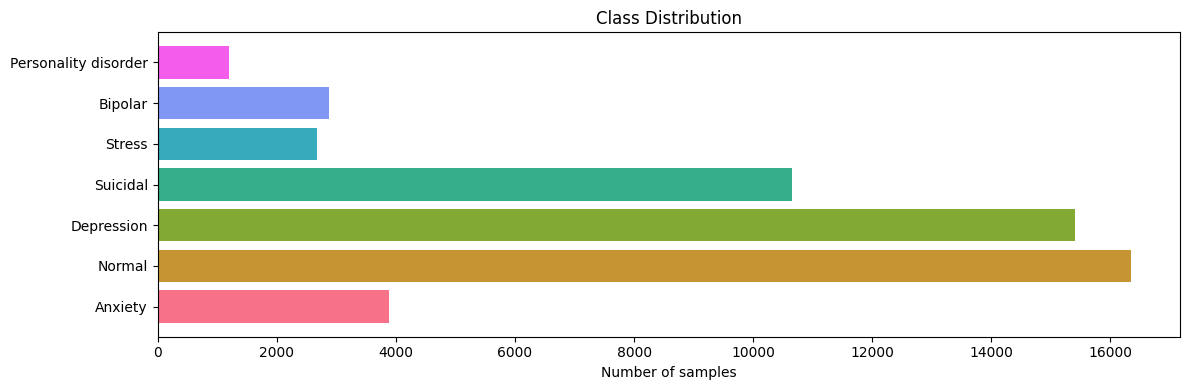


Class counts:
  [ 0] Anxiety                                          — 3888 samples
  [ 1] Normal                                           — 16351 samples
  [ 2] Depression                                       — 15404 samples
  [ 3] Suicidal                                         — 10653 samples
  [ 4] Stress                                           — 2669 samples
  [ 5] Bipolar                                          — 2877 samples
  [ 6] Personality disorder                             — 1201 samples


In [5]:
label_map = (
    df[['class_num', 'class_txt']]
    .drop_duplicates()
    .sort_values('class_num')
    .set_index('class_num')['class_txt']
    .to_dict()
)

counts = df['class_num'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
bars = plt.barh(
    [label_map[i] for i in counts.index],
    counts.values,
    color=sns.color_palette("husl", len(counts))
)
plt.xlabel("Number of samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

print("\nClass counts:")
for cls, cnt in counts.items():
    print(f"  [{cls:>2}] {label_map[cls]:<48} — {cnt} samples")

count    52410.000000
mean       113.738676
std        163.958816
min          2.000000
25%         16.000000
50%         63.000000
75%        149.000000
max       6300.000000
Name: text_len, dtype: float64


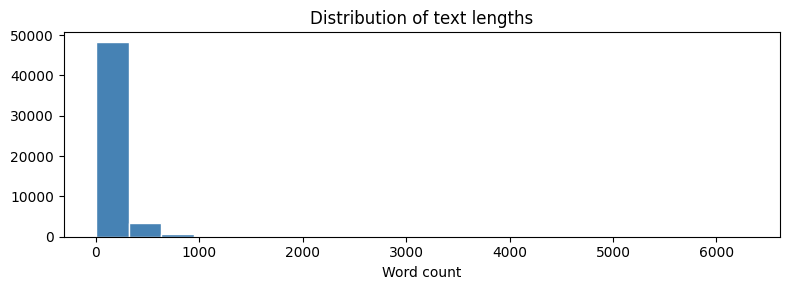

In [6]:
# Text length distribution
df['text_len'] = df['health_concerns'].str.split().str.len()
df = df[df['text_len'] > 1]
print(df['text_len'].describe())

plt.figure(figsize=(8, 3))
plt.hist(df['text_len'], bins=20, color='steelblue', edgecolor='white')
plt.xlabel("Word count")
plt.title("Distribution of text lengths")
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

In [7]:
NUM_LABELS = df['class_num'].nunique()
print(f"Number of classes: {NUM_LABELS}")

X = df['health_concerns'].tolist()
y = df['class_num'].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y          # preserve class balance
)

print(f"Train samples : {len(X_train)}")
print(f"Val   samples : {len(X_val)}")

Number of classes: 7
Train samples : 41928
Val   samples : 10482


## 5. Tokenizer & PyTorch Dataset

In [8]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 256        # Most texts fit well under 256 tokens

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'token_type_ids': self.encodings['token_type_ids'][idx],
            'labels':         self.labels[idx]
        }


train_dataset = MentalHealthDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = MentalHealthDataset(X_val,   y_val,   tokenizer, MAX_LEN)

BATCH_SIZE = 64   # Lower if GPU memory is tight; increase for faster training

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print("Tokenisation complete.")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenisation complete.
Train batches: 656  |  Val batches: 164


## 6. Model Setup

In [9]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    hidden_dropout_prob=0.3,         # regularisation
    attention_probs_dropout_prob=0.3
)
model = model.to(DEVICE)

# Hyperparameters
EPOCHS       = 5
LR           = 2e-5
WARMUP_STEPS = 0

total_steps  = len(train_loader) * EPOCHS

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Training for {EPOCHS} epochs  ({total_steps} optimiser steps)")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded — 109,487,623 parameters
Training for 5 epochs  (3280 optimiser steps)


## 7. Training Loop

In [10]:
from tqdm import tqdm


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            token_type_ids = batch['token_type_ids'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_labels, all_preds


history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1   = 0.0
best_model_path = "best_bert_mental_health.pt"

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    print(f"Epoch {epoch}...")
    model.train()
    running_loss = 0.0

    for step, batch in tqdm(enumerate(train_loader, 1), total=len(train_loader)):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += outputs.loss.item()

    train_loss = running_loss / len(train_loader)

    # ── Validation ──
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(
        f"Epoch {epoch:>2}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  "
        f"val_acc={val_acc:.4f}  "
        f"val_f1={val_f1:.4f}"
    )

    # Save best checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"    ✓ Best model saved (val_f1={best_val_f1:.4f})")

print(f"\nTraining complete. Best val F1: {best_val_f1:.4f}")

Epoch 1...


100%|██████████| 656/656 [32:11<00:00,  2.94s/it]


Epoch  1/5  train_loss=0.8143  val_loss=0.5514  val_acc=0.7818  val_f1=0.7778
    ✓ Best model saved (val_f1=0.7778)
Epoch 2...


100%|██████████| 656/656 [32:25<00:00,  2.97s/it]


Epoch  2/5  train_loss=0.5085  val_loss=0.4811  val_acc=0.8092  val_f1=0.8106
    ✓ Best model saved (val_f1=0.8106)
Epoch 3...


...

Epoch  3/5  train_loss=0.4362  val_loss=0.4778  val_acc=0.8166  val_f1=0.8189
    ✓ Best model saved (val_f1=0.8189)
Epoch 4...


100%|██████████| 656/656 [32:24<00:00,  2.96s/it]


Epoch  4/5  train_loss=0.3970  val_loss=0.4642  val_acc=0.8256  val_f1=0.8265
    ✓ Best model saved (val_f1=0.8265)
Epoch 5...


100%|██████████| 656/656 [32:23<00:00,  2.96s/it]


Epoch  5/5  train_loss=0.3714  val_loss=0.4620  val_acc=0.8243  val_f1=0.8247

Training complete. Best val F1: 0.8265


## 8. Training Curves

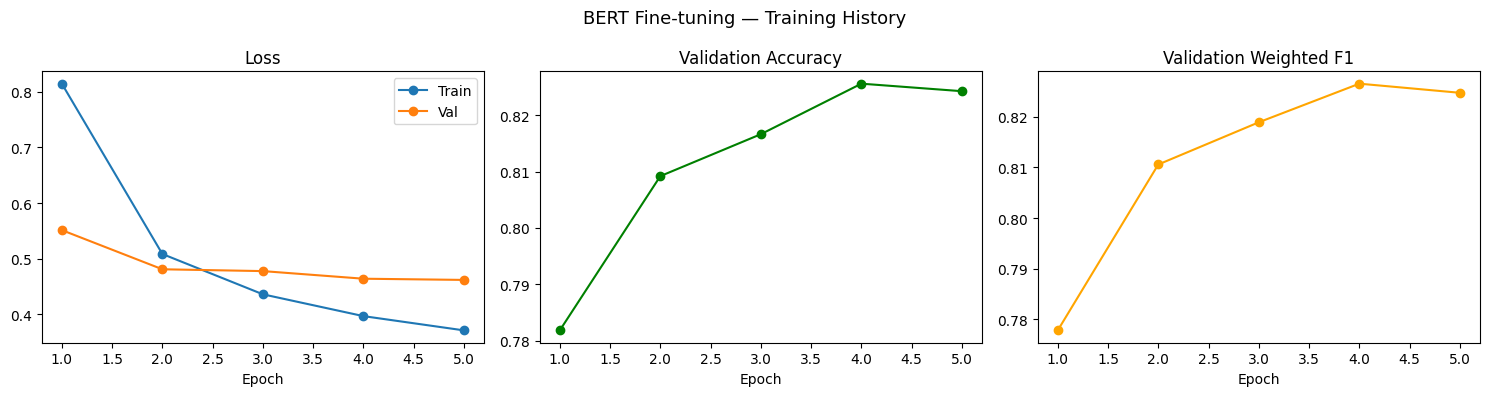

In [11]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], color='green', marker='o')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_f1'], color='orange', marker='o')
axes[2].set_title('Validation Weighted F1'); axes[2].set_xlabel('Epoch')

plt.suptitle('BERT Fine-tuning — Training History', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Evaluate Best Model

In [12]:
# Reload best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

val_loss, val_acc, val_f1, true_labels, pred_labels = evaluate(model, val_loader)

print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Validation F1 (w)   : {val_f1:.4f}")
print()
print(classification_report(
    true_labels, pred_labels,
    target_names=[label_map[i] for i in range(NUM_LABELS)]
))

Validation Loss     : 0.4642
Validation Accuracy : 0.8256
Validation F1 (w)   : 0.8265

                      precision    recall  f1-score   support

             Anxiety       0.85      0.84      0.84       768
              Normal       0.96      0.95      0.95      3218
          Depression       0.80      0.77      0.78      3079
            Suicidal       0.74      0.74      0.74      2130
              Stress       0.58      0.85      0.69       517
             Bipolar       0.83      0.84      0.84       555
Personality disorder       0.86      0.54      0.66       215

            accuracy                           0.83     10482
           macro avg       0.80      0.79      0.79     10482
        weighted avg       0.83      0.83      0.83     10482



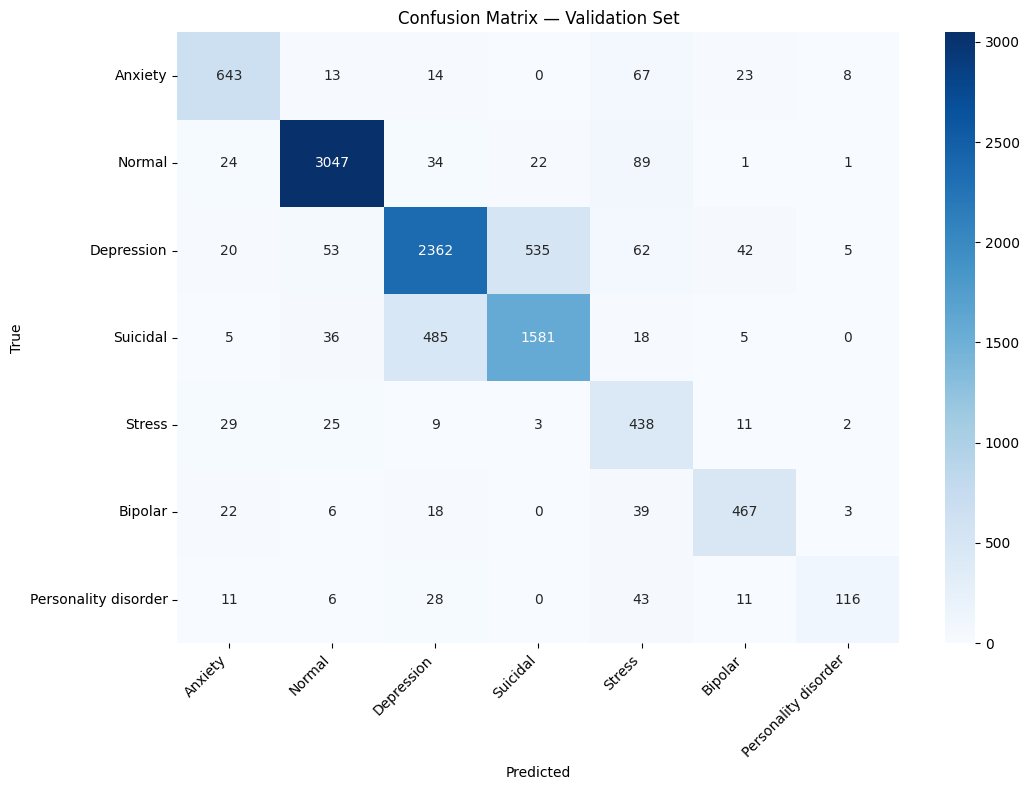

In [13]:
# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
short_labels = [
    label_map[i].replace('Disorder', 'Dis.').replace('Generalized Anxiety', 'GAD')
    for i in range(NUM_LABELS)
]

plt.figure(figsize=(11, 8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=short_labels,
    yticklabels=short_labels,
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Validation Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Inference on New Patient Text

In [14]:
def predict(text: str, model=model, tokenizer=tokenizer,
            max_len=MAX_LEN, device=DEVICE, label_map=label_map):
    """Return predicted class_num, diagnosis label, and class probabilities."""
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids      = encoding['input_ids'].to(device),
            attention_mask = encoding['attention_mask'].to(device),
            token_type_ids = encoding['token_type_ids'].to(device)
        )
    probs      = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    class_num  = int(probs.argmax())
    diagnosis  = label_map[class_num]
    confidence = probs[class_num]
    return class_num, diagnosis, confidence, probs


# ── Demo ──
sample_texts = [
    # Likely anxiety
    "I can't stop worrying about everything. Even small things feel catastrophic and I'm always waiting for something bad to happen.",
    # Likely depression
    "I've lost all interest in things I used to enjoy. Getting out of bed feels impossible and I feel completely empty.",
    # Likely PTSD
    "I keep having nightmares about the accident. A car backfiring sends me into a panic and I avoid driving completely.",
]

for text in sample_texts:
    cls, diag, conf, probs = predict(text)
    print(f"Text     : {text[:90]}...")
    print(f"Diagnosis: [{cls}] {diag}  (confidence: {conf:.1%})")
    print()

Text     : I can't stop worrying about everything. Even small things feel catastrophic and I'm always...
Diagnosis: [0] Anxiety  (confidence: 67.3%)

Text     : I've lost all interest in things I used to enjoy. Getting out of bed feels impossible and ...
Diagnosis: [2] Depression  (confidence: 70.6%)

Text     : I keep having nightmares about the accident. A car backfiring sends me into a panic and I ...
Diagnosis: [4] Stress  (confidence: 91.6%)



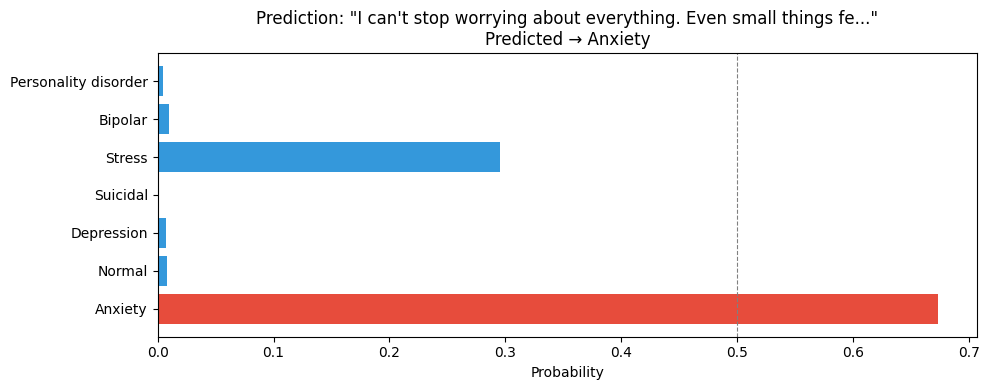

In [15]:
# Visual probability bar chart for a single prediction
text_to_inspect = sample_texts[0]
cls, diag, conf, probs = predict(text_to_inspect)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if i == cls else '#3498db' for i in range(NUM_LABELS)]
ax.barh([label_map[i] for i in range(NUM_LABELS)], probs, color=colors)
ax.set_xlabel('Probability')
ax.set_title(f'Prediction: "{text_to_inspect[:60]}..."\nPredicted → {diag}')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 11. Save Full Model & Tokenizer

In [16]:
SAVE_DIR = "bert_mental_health_model"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save the label map for downstream use
import json
with open(f"{SAVE_DIR}/label_map.json", "w") as f:
    json.dump({str(k): v for k, v in label_map.items()}, f, indent=2)

print(f"Model, tokenizer, and label map saved to './{SAVE_DIR}/'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model, tokenizer, and label map saved to './bert_mental_health_model/'


## 12. Load & Use Saved Model (standalone example)

In [17]:
# from transformers import BertForSequenceClassification, BertTokenizer
# import json, torch

# SAVE_DIR = "bert_mental_health_model"

# loaded_tokenizer = BertTokenizer.from_pretrained(SAVE_DIR)
# loaded_model     = BertForSequenceClassification.from_pretrained(SAVE_DIR)
# loaded_model     = loaded_model.to(DEVICE)

# with open(f"{SAVE_DIR}/label_map.json") as f:
#     loaded_label_map = {int(k): v for k, v in json.load(f).items()}

# # Test
# test_text = "I feel paralysed by sadness. Nothing excites me anymore and I sleep 14 hours a day."
# cls, diag, conf, _ = predict(
#     test_text,
#     model=loaded_model,
#     tokenizer=loaded_tokenizer,
#     label_map=loaded_label_map
# )
# print(f"Text      : {test_text}")
# print(f"Diagnosis : [{cls}] {diag}  ({conf:.1%} confidence)")